In [ ]:
import sys
sys.path.append('../data')


import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
plt.style.use('../data/deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from IPython.display import display, Markdown, Latex
from sklearn.datasets import make_blobs
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from lab_utils_softmax import plt_softmax
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

The softmax function can be written:
$$a_j = \frac{e^{z_j}}{ \sum_{k=1}^{N}{e^{z_k} }} \tag{1}$$

In [5]:
def my_softmax(z):
    ez = np.exp(z)
    sm = ez / np.sum(ez)
    return (sm)

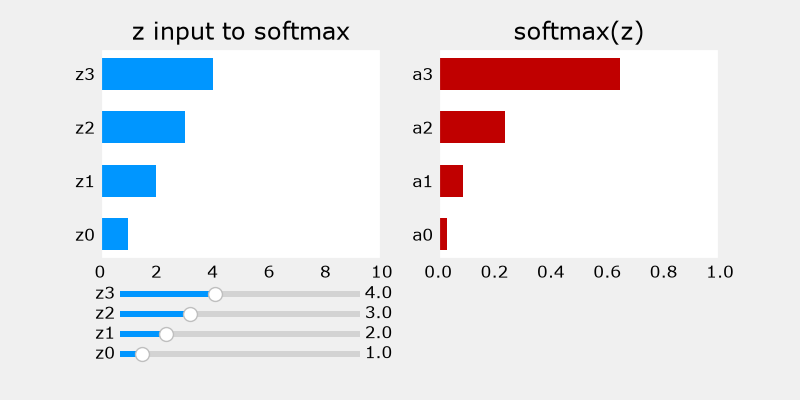

In [7]:
plt.close('all')
plt_softmax(my_softmax)

In [9]:
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train,Y_train = make_blobs(n_samples= 2000, centers= centers , cluster_std=1.0,random_state=30)



In [11]:
model = Sequential(
    [
        Dense(25,activation='relu'),
        Dense(15,activation='relu'),
        Dense(4,activation='softmax'),

    ]
)

In [13]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(0.001)
)

In [14]:
model.fit(
    X_train,Y_train,
    epochs = 10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - loss: 0.9018 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - loss: 0.3802
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.1815
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - loss: 0.1078
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - loss: 0.0790
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - loss: 0.0650
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 0.0570
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - loss: 0.0507
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.0469
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.0434


In [ ]:
p_nonprefered = model.predict(X_train)
print(p_nonprefered [:2])
print(f"Largest value : {np.max(p_nonprefered)} , Smallest value :  {np.min(p_nonprefered)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step
[[3.09e-03 3.43e-03 9.72e-01 2.10e-02]
 [9.95e-01 4.36e-03 1.63e-04 8.22e-05]]
Largest value : 0.9999980926513672 , Smallest value :  3.724046848674334e-09


In [17]:
model = Sequential(
    [
        Dense(25,activation='relu'),
        Dense(15,activation='relu'),
        Dense(4,activation='linear'),

    ]
)

In [18]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001)
)

In [19]:
model.fit(
    X_train,Y_train,
    epochs = 10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 1.0399 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - loss: 0.3934
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 0.1759
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - loss: 0.1097
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.0829
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 0.0695
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.0612
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.0558
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - loss: 0.0514
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - loss: 0.0476


In [21]:
p_prefered = model.predict(X_train)
print(p_prefered [:2])
print(f"Largest value : {np.max(p_prefered)} , Smallest value :  {np.min(p_prefered)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step
[[-3.22 -3.48  1.95 -1.53]
 [ 3.79 -1.1  -2.94 -7.22]]
Largest value : 10.779045104980469 , Smallest value :  -13.958699226379395


In [23]:
sm_prefered = tf.nn.softmax(p_prefered).numpy()
print(sm_prefered [:2])
print(f"Largest value : {np.max(sm_prefered)} , Smallest value :  {np.min(sm_prefered)}")

[[5.50e-03 4.21e-03 9.61e-01 2.96e-02]
 [9.91e-01 7.42e-03 1.18e-03 1.64e-05]]
Largest value : 0.9999970197677612 , Smallest value :  1.2082591593909342e-09
